### The purpose of the Landscape Notebook is to perform analysis and give an overview of how AI is spread across regions and industries

In [2]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt

#### set data into df

In [3]:
# Import ai industry csv using pandas - it exists one dir up and in Data
df_industry = pd.read_csv("../Data/ai_industry_summary.csv") 


In [4]:
df_company = pd.read_csv("../Data/ai_company_adoption.csv") 

In [5]:
df_country = pd.read_csv("../Data/country_ai_index.csv") 

Next is the basic bar chart set to show spread of AI adoption across industry

Text(0, 0.5, 'AI Adoption Rate %')

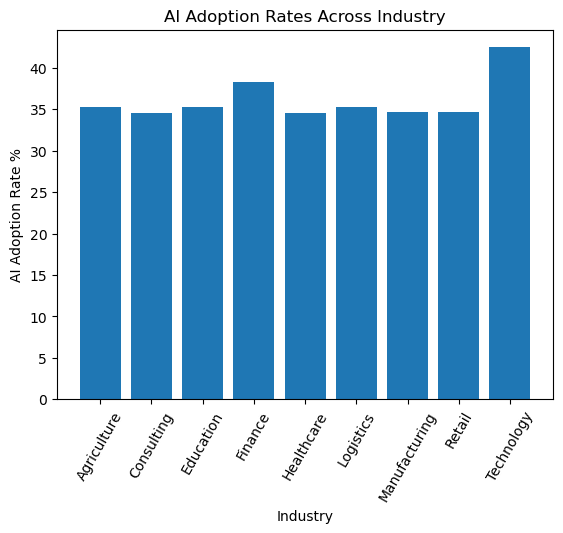

In [6]:
# Plot bar chart of AI Adoption Rates by Industry
plt.bar(df_industry['industry'], df_industry["avg_ai_adoption_rate"])
plt.title("AI Adoption Rates Across Industry")
plt.xticks(rotation=60)
plt.xlabel("Industry")
plt.ylabel("AI Adoption Rate %")

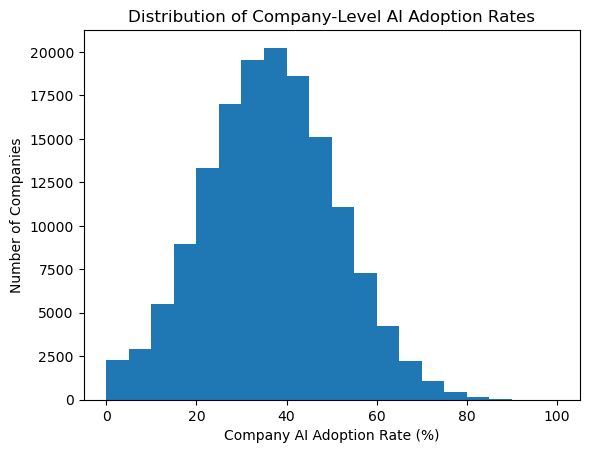

In [ ]:
#Histogram to show how many companies fall into each adoption percent category
plt.hist(
    df_company["ai_adoption_rate"],
    bins=20
)

plt.xlabel("Company AI Adoption Rate (%)")
plt.ylabel("Number of Companies")
plt.title("Distribution of Company-Level AI Adoption Rates")

plt.show()

The next cell is an enhancement of the basic bar chart above. The chart was flipped to horizontal for easier reading and has highlights for leaders in ai adoption

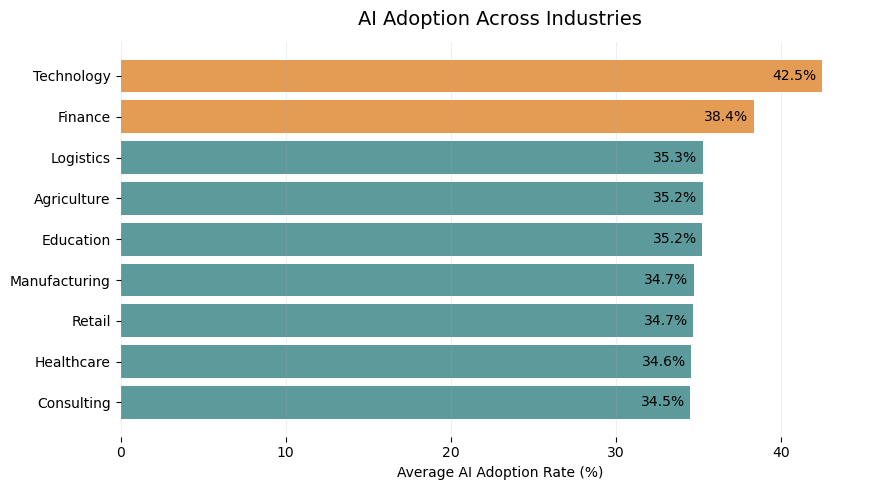

In [8]:
import matplotlib.pyplot as plt

# sorted by adoption rate instead of industry to make the chart flow
df_industry_sorted = df_industry.sort_values(
    "avg_ai_adoption_rate",
    ascending=True
)
# Highlighting finance and industry as two leaders
colors = [
    "#e49c54" if industry in ["Technology", "Finance"] else "#5d9a9c"
    for industry in df_industry_sorted["industry"]
]

fig, ax = plt.subplots(figsize=(9, 5))

#horizontal bar chart using sorted industry and adoption rate columns and using set colors from above
bars = ax.barh(
    df_industry_sorted["industry"],
    df_industry_sorted["avg_ai_adoption_rate"],
    color=colors
)
for bar in bars:
    width = bar.get_width() # calculating width of bar for label placement below

    ax.text(
        width - 3 , # moves the label inside the bar
        bar.get_y() + bar.get_height()/2, # y location of label - halfway up the bar height
        f"{width:.1f}%",
        va="center", # puts center of text on
        fontsize=10
    )

ax.set_title(
    "AI Adoption Across Industries",
    fontsize=14,
    pad=12
)

ax.set_xlabel("Average AI Adoption Rate (%)")
ax.set_ylabel("")

ax.set_xlim(0, 46)
ax.grid(axis="x", alpha=0.2)

# Removing spines for cleaner look
ax.spines["top"].set_visible(False) 
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)

plt.tight_layout()
plt.show()

In [9]:
#calculation for choropleth 
# Group by country and ai adoption rate, grab the mean, and reset index
# Takes company records to country level by grabbing mean for each country
country_ai = (
    df_company
    .groupby("country")["ai_adoption_rate"]
    .mean()
    .reset_index()
)

country_ai.head()

,country,ai_adoption_rate
0,Argentina,34.327419
1,Australia,39.933564
2,Brazil,36.674198
3,Canada,39.120333
4,Chile,36.461705


In [10]:
# Checking to see if there are similar row counts for each country
df_company["country"].value_counts()

country
France          5637
Japan           5629
South Korea     5443
Germany         5327
Chile           5190
Egypt           5125
Netherlands     5118
Philippines     5091
Poland          5086
USA             5058
New Zealand     5058
UK              5027
South Africa    5003
Italy           4963
Australia       4944
India           4941
Colombia        4918
Indonesia       4915
Brazil          4907
Argentina       4894
Sweden          4881
Kenya           4871
Singapore       4854
Spain           4796
Nigeria         4788
Thailand        4782
Malaysia        4718
Canada          4682
Vietnam         4677
China           4677
Name: count, dtype: int64

In [11]:
# This is a later and edited version of the choroplth
# It exists in executive level powerpoint as well as a live version can be opened from README
# The chart shows what average ai adoption % is for companies within each of these 30 countries

fig = px.choropleth(
    country_ai,
    locations="country",
    locationmode="country names",
    color="ai_adoption_rate",
    hover_name="country",
    color_continuous_scale="Plasma",
    range_color=(30,41),
    projection="natural earth",
    labels={
        "ai_adoption_rate": "Avg AI Adoption Rate (%)"
    },
    title="Global AI Adoption Intensity by Country"
)

fig.update_traces(
    marker_line_color="white",
    marker_line_width=0.4,
    hovertemplate=
        "<b>%{hovertext}</b><br>" +
        "AI Adoption Rate: %{z:.1f}%<extra></extra>"
)

fig.update_layout(

    # background
    paper_bgcolor="rgb(245,248,250)",
    plot_bgcolor="rgb(245,248,250)",

    title={
        "text": "Global AI Adoption Intensity by Country",
        "x": .5,
        "xanchor": "center",
        "font": {
            "size": 24,
            "color": "rgb(30,30,30)"
        }
    },

# Editing map feature colors
    geo=dict(
        showframe=False,
        showcoastlines=True,

        showocean=True,
        oceancolor="#3FAAA5",

        showland=True,
        landcolor="rgb(215,220,220)",

        coastlinecolor="white",
        countrycolor="white",

        projection_type="natural earth"
    ),

# Changing color saturation bar
    coloraxis_colorbar=dict(
        title="AI Adoption<br>Rate (%)",
        ticksuffix="%", # adds a suffix to everything on color bar 
        thickness=15
    ),

    margin=dict( # Editing empty space size
        l=20,
        r=20,
        t=70,
        b=20
    )
)


fig.show()

C:\Users\patri\AppData\Local\Temp\ipykernel_34236\503757869.py:5: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


The next few cells evaluate the usefulness of looking at what percent of companies reported adopting AI in the dataset per country. After realizing the range was so small, I decided against using this metric. 

In [12]:
# showing what comapnies have adopted SOME level of ai (not including 'none')

df_company["has_adopted_ai"] = (
    df_company["ai_adoption_stage"] != "none"
)

In [13]:
country_adoption_percent = (
    df_company
    .groupby("country")["has_adopted_ai"]
    .mean()
    .reset_index()
)

country_adoption_percent.head()

,country,has_adopted_ai
0,Argentina,0.954434
1,Australia,0.979571
2,Brazil,0.967190
3,Canada,0.978642
4,Chile,0.964355


In [14]:
country_adoption_percent.min()


country           Argentina
has_adopted_ai     0.941073
dtype: object

In [15]:
country_adoption_percent.max()

country            Vietnam
has_adopted_ai    0.981218
dtype: object

In [16]:
# Shows most companies are in transition phase
df_company["ai_adoption_stage"].value_counts()

ai_adoption_stage
partial    78800
pilot      64317
none        5198
full        1685
Name: count, dtype: int64